# White Noise to Assess the Effect of Measurement Uncertainty

The reported accuracy of the MODIS EVI product is ±0.015  
(see MODIS Land Product General Accuracy Statement: https://modis-land.gsfc.nasa.gov/ValStatus.php?ProductID=MOD13).

To assess the impact of measurement uncertainty on the wavelet analysis, a Monte Carlo experiment is performed in which white noise is generate to mimic mesurment error

### Choice of Noise Amplitude

The noise is sampled from a normal distribution with standard deviation:


$\sigma = 0.015 / 2 = 0.0075$

This choice is motivated by the following assumptions:

- The reported EVI uncertainty is ±0.015.
- Measurement errors are assumed to be normally distributed and centered on each observed EVI value.
- The ±0.015 uncertainty range is interpreted as encompassing approximately 95% of the error distribution.
- Under the empirical **68–95–99.7 rule** for a normal distribution, approximately 95% of values lie within ±2σ.
- Therefore, if ±0.015 corresponds to ±2σ, the implied standard deviation is $\sigma = 0.015 / 2 = 0.0075$

This assumption is conservative and avoids underestimating the effect of measurement uncertainty.

### Alternative Interpretation

If the ±0.015 uncertainty were instead interpreted as representing the 99.7% confidence interval (±3σ), the corresponding standard deviation would be:


$\sigma = 0.015 / 3 = 0.005$


Using σ = 0.0075 therefore represents a cautious choice that slightly overestimates uncertainty, ensuring that the Monte Carlo analysis captures a realistic upper bound on noise-induced variability.


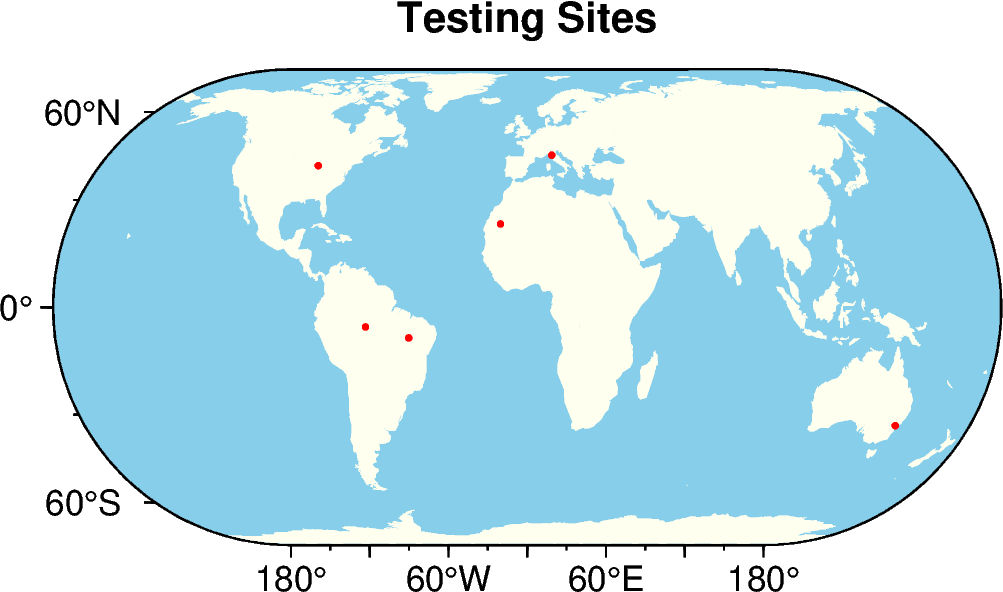

In [ ]:
import xarray as xr
import numpy as np
import pygmt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# importing wavelet functions
from wavelets_wrapper.quick_wavelet import run_full_wavelet_analysis

# Open dataset of EVI once with chunking (chunks={"time": -1})
evi = xr.open_dataset('EVI_time_series_scales_interpolated_nearest_v2.nc', chunks={"time": -1})

# import csv with coordinates of points to extract and check confidence (test points)
# coordinates of sample points
data = {
    'longitude': [-61.67, 10.6365156, 150.34574545696321, -88.45863661708249, -45.33555915051746, -10.49 ],
    'latitude': [-5.35, 43.9814466, -33.331799361418646, 40.530269526398435, -8.39752127849006, 23 ],
    'name': ["1. Amazon forest in Brazil", "2. Deciduous forest in Italy", "3. Fire disturbance in Eastern Australia", "4. Cropland in the USA", "5. Forest to cropland transition in Brazil", "6. Mauritania desert"],
    'ID': ["Site1", "Site2", "Site3", "Site4", "Site5", "noise_site"],
    'color': [ '#701f57', '#ad1759', '#e13342', '#f37651', '#f6b48f', '#abcdef'],
    'number': [1, 2, 3, 4, 5, 6]
    }

coords_df = pd.DataFrame(data)

# map the points to see where they are
# Create a figure
fig = pygmt.Figure()
# Add a base map
with pygmt.config(FONT_TITLE="10p", MAP_TITLE_OFFSET="-2p", MAP_ANNOT_OFFSET="2p"):
    fig.basemap(region="d", projection="Kf8c", frame=["af", "+tTesting Sites"])
# Add coastlines
fig.coast(water="skyblue", land="ivory", resolution="c", area_thresh="10000/0/1")
# Plot each point with unique color and legend label
for i, row in coords_df.iterrows():
    fig.plot(x=row['longitude'], y=row['latitude'], style="c0.05c", fill="red", pen="red", label=f"Site {i+1}")
# fig show
fig.show()


In [18]:
# generate color palette from sns viridis with number of colours equal to number of rows in coords_df, we might use this later for plotting
n_colors = len(coords_df)
# make viridis hex
palette = sns.color_palette("Set2", n_colors=n_colors).as_hex()


In [6]:
####################################
########## GENERATE NOISE ##########
####################################
# setting the parameter per create 1000 noise timeseries
number_of_repetitions = 1000
length_of_signal = evi.sizes['time']
error = 0.015
Standard_deviation = error / 2  # Standard Deviation for white noise
main_seed = 260895  # one master seed for full reproducibility

# generate a seed sequuence
seeds_sequence = np.random.SeedSequence(main_seed)
# n number o child seeds
child_seeds = seeds_sequence.spawn(number_of_repetitions)

# feeding each child seed to a new rng and store them in a list and then make a normal distribution noise for each child seed
rngs = [np.random.default_rng(s) for s in child_seeds]
noise_timeseries = [rng.normal(0, Standard_deviation, length_of_signal) for rng in rngs] # normally distributed noise


In [7]:
# Run wavelet analysis for each noise timeseries and store the results in a list
sumpower_dfs_noisy = []
fft_noise_list = []

############# RUN WAVELET FOR NOISE #############
for i, noise in enumerate(noise_timeseries):

    times = evi.time.values
    time_vals = (times - times[0]) / np.timedelta64(1, 'D')  # Time in days as float

    ####################################
    ####### RUN WAVELET ANALYSIS #######
    ####################################
    _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, wavelet_power_df_mirrored_noise = run_full_wavelet_analysis(noise, dt=16, mirror=True, wf='morlet', dj=0.1, om0=6, normmean=False, mirrormethod=3)
    _, _, _, _, _, _, _, fft, _, _, _, _, _, _, _, _, _ = run_full_wavelet_analysis(noise, dt=16, mirror=False, wf='morlet', dj=0.1, om0=6, normmean=False, mirrormethod=3)
    original_length = len(noise)
    start_index = 4 * original_length  # 5th repetition starts at (4 * original_length)
    end_index = 5 * original_length    # 5th repetition ends at (5 * original_length)

    #####################################
    ### DEALING WITH MIRRORRED RESULT ###
    #####################################

    # Because I mirrored the signal, there ia a lot of power that needs to be removed before plotting everything:
    # - I need to remove the power generated at periods greater than the length of the signal
    # - I also want to isolate power in the central domain (time-wise). 

    extended_time = wavelet_power_df_mirrored_noise["time"].unique()
    # Define windows to remove excess power
    time_min = extended_time[start_index]
    time_max = extended_time[end_index]    
    period_min = 32    
    period_max = time_vals[-1]

    wavelet_power_df_noise = wavelet_power_df_mirrored_noise.copy() # Create a copy of the DataFrame so that we can store it separatelly

    # Apply the filter
    wavelet_power_df_noise = wavelet_power_df_noise[
        (wavelet_power_df_noise["time"] >= time_min) & 
        (wavelet_power_df_noise["time"] <= time_max) &
        (wavelet_power_df_noise["period"] >= period_min) &
        (wavelet_power_df_noise["period"] <= period_max)
    ]

    # change time value to restore the original time
    wavelet_power_df_noise["time"] = wavelet_power_df_noise["time"] - time_min
    wavelet_power_df_noise = wavelet_power_df_noise.reset_index()

    # overwrite the sumpower_df with the correct values for the selected windows
    sumpower_df_noise = wavelet_power_df_noise.groupby("period")[["rectified_power", "power"]].mean().reset_index()
    sumpower_df_noise["frequency"] = 1 / sumpower_df_noise["period"]

    # append to the list
    sumpower_dfs_noisy.append(sumpower_df_noise)
    fft_noise_list.append(fft)


Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculating filtered ICWTs...
Not calculatin

In [8]:
# Calculating mean and std of the all the noise spectra I generated

# preserving 'period' and 'frequency'
stats_noise = sumpower_dfs_noisy[0][["period", "frequency"]].copy()

# stack rectified_power values into a 2D array (rows = data points, columns = replicas)
rectified_stack = np.column_stack([df["rectified_power"].values for df in sumpower_dfs_noisy])
print(rectified_stack.shape)  # Should be: (number of periods, number of replicas)

# compute stats along columns
stats_noise["mean_rect_power"] = np.mean(rectified_stack, axis=1)
stats_noise["p25"]  = np.percentile(rectified_stack, 25, axis=1)
stats_noise["p75"]  = np.percentile(rectified_stack, 75, axis=1)
stats_noise["p95"]  = np.percentile(rectified_stack, 95, axis=1)


####  doing the same for fft
fft_noise = fft_noise_list[0][["frequency"]].copy()
fft_stack = np.column_stack([fft_noise["power"].values for fft_noise in fft_noise_list])
print(fft_stack.shape)  # Should be: (number of periods, number of replicas)

# compute stats along columns
fft_noise["mean_power"] = np.mean(fft_stack, axis=1)
fft_noise["p25"]  = np.percentile(fft_stack, 25, axis=1)
fft_noise["p75"]  = np.percentile(fft_stack, 75, axis=1)



#### doing the same for unrectified power
stats_noise_unrect = sumpower_dfs_noisy[0][["period", "frequency"]].copy()

# Stack rectified_power values into a 2D array (rows = data points, columns = replicas)
unrectified_stack = np.column_stack([df["power"].values for df in sumpower_dfs_noisy])
print(unrectified_stack.shape)  # Should be: (number of periods, number of replicas)

# Compute statistics along columns
stats_noise_unrect["mean_power"] = np.mean(unrectified_stack, axis=1)
stats_noise_unrect["p25"]  = np.percentile(unrectified_stack, 25, axis=1)
stats_noise_unrect["p75"]  = np.percentile(unrectified_stack, 75, axis=1)


# print to check
print(fft_noise.head())
print(stats_noise.head())
print(stats_noise_unrect.head())

(82, 1000)
(287, 1000)
(82, 1000)
   frequency    mean_power           p25           p75
0   0.000109  3.973262e-07  1.106906e-07  5.509155e-07
1   0.000218  3.958131e-07  1.152901e-07  5.176919e-07
2   0.000327  4.072179e-07  1.151776e-07  5.688831e-07
3   0.000436  3.716179e-07  1.035120e-07  5.096109e-07
4   0.000544  3.770779e-07  1.092792e-07  5.384822e-07
      period  frequency  mean_rect_power       p25       p75       p95
0  33.057397   0.030250         0.000001  0.000001  0.000001  0.000001
1  35.430041   0.028225         0.000001  0.000001  0.000001  0.000002
2  37.972977   0.026335         0.000001  0.000001  0.000002  0.000002
3  40.698429   0.024571         0.000001  0.000001  0.000001  0.000002
4  43.619496   0.022926         0.000001  0.000001  0.000001  0.000002
      period  frequency  mean_power       p25       p75
0  33.057397   0.030250    0.000037  0.000034  0.000040
1  35.430041   0.028225    0.000048  0.000044  0.000051
2  37.972977   0.026335    0.000054  0.000

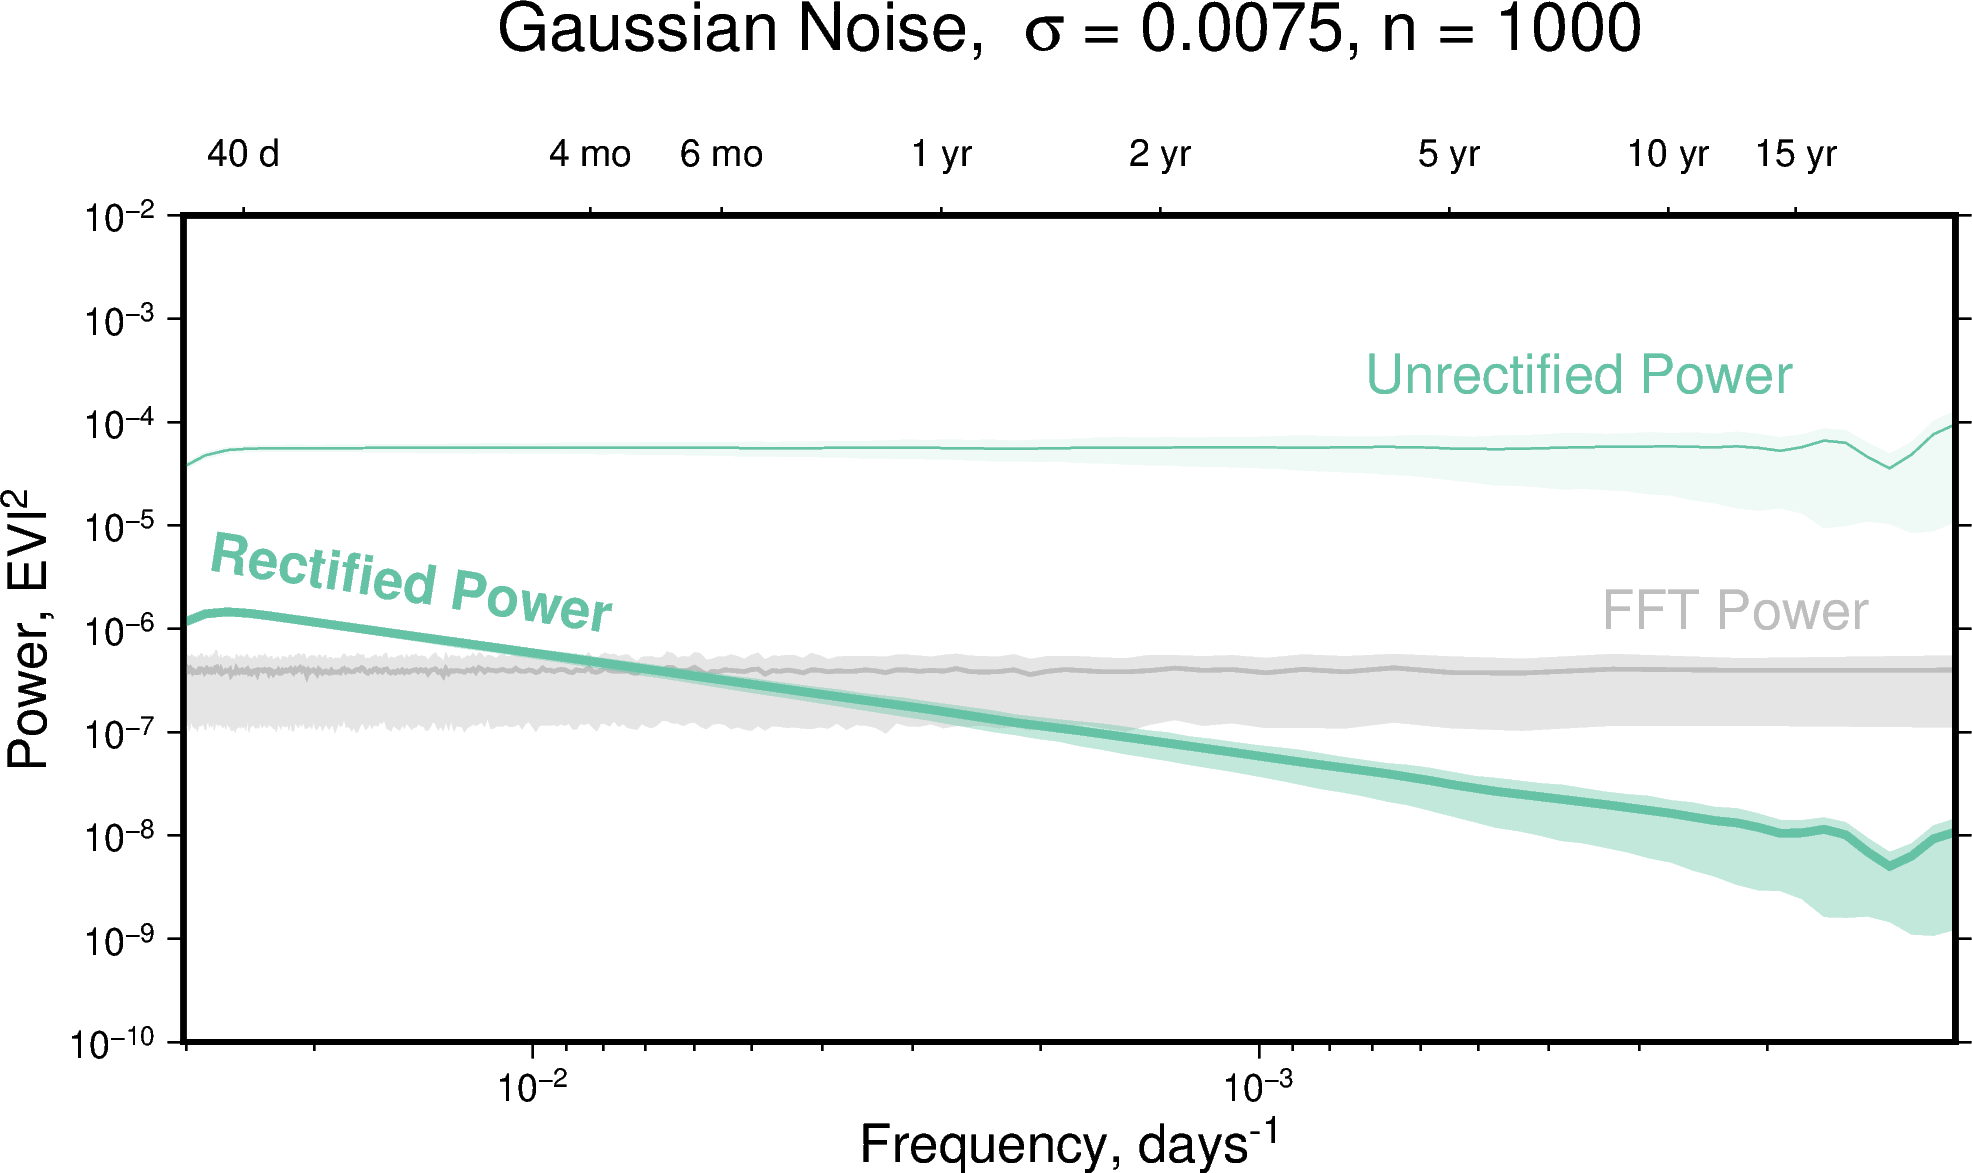

In [9]:
  
########## PLOTTING ##########
# calculating mean and std of the sumpower_dfs_noisy

# GMT PLOTTING
fig=pygmt.Figure()

# add one plot to compare power
fig.shift_origin(xshift="4c", yshift="5c")
# fig.basemap(region=[ min(base['frequency']), max(base['frequency']), min(base['mean_rect_power']), max(base['mean_rect_power'])], projection="X-15cl/7cl",  frame=["SWe", 'xa1f3p+lFrequency, days@+-1@+' ,'ya1p+lPower, EVI@+2@+'])
fig.basemap(region=[ min(stats_noise['frequency']), max(stats_noise['frequency']), 1e-10, 1e-2], projection="X-15cl/7cl",  frame=["SWe", 'xa1f3p+lFrequency, days@+-1@+' ,'ya1p+lPower, EVI@+2@+'])

# plot the interquantile range -FFT
fig.plot(
    x=list(fft_noise["frequency"]) + list(fft_noise["frequency"][::-1]),
    y=list(fft_noise["p25"]) + list(fft_noise["p75"][::-1]), transparency=60, fill="gray")
fig.plot(x=fft_noise["frequency"], y=fft_noise["mean_power"], pen="1p,gray", label="Mean FFT power") #mean line

# plot the interquantile range -wavelet unrectified
fig.plot(
    x=list(stats_noise_unrect["frequency"]) + list(stats_noise_unrect["frequency"][::-1]),
    y=list(stats_noise_unrect["p25"]) + list(stats_noise_unrect["p75"][::-1]), transparency=90, fill=f"{palette[0]}")   
fig.plot(x=stats_noise_unrect["frequency"], y=stats_noise_unrect["mean_power"], pen=f"0.5p,{palette[0]}", label="Mean WT unrectified power") #mean line

# plot the interquantile range -wavelet
fig.plot(
    x=list(stats_noise["frequency"]) + list(stats_noise["frequency"][::-1]),
    y=list(stats_noise["p25"]) + list(stats_noise["p75"][::-1]), transparency=60, fill=f"{palette[0]}")
fig.plot(x=stats_noise["frequency"], y=stats_noise["mean_rect_power"], pen=f"2p,{palette[0]}", label="Mean WT rectified power") #mean line

# Add text annotations
fig.basemap(region=[0, 15, 0, 7], projection="X15c/7c",  frame=["swne"])
fig.text(x=10, y=5.5, text="Unrectified Power", font=f"13p,Helvetica,{palette[0]}", justify="BL")
fig.text(x=0.2, y=4, text="Rectified Power", font=f"13p,Helvetica-Bold,{palette[0]}", justify="BL", angle=-9)
fig.text(x=12, y=3.5, text="FFT Power", font="13p,Helvetica,gray", justify="BL")


# add period frame
fig.shift_origin(yshift="7c")
fig.basemap(region=[ stats_noise['period'].min(),stats_noise['period'].max(), 0,5], projection="X15cl/7c",  frame=["S"] )
ticks = [40, 120, 182, 365, 730, 1825, 3650, 5475]
lables = ['40 d', '4 mo', '6 mo', '1 yr', '2 yr', '5 yr', '10 yr', '15 yr']
# Add custom ticks using annotations
for tick, label in zip(ticks, lables):
    # Add ticks manually using annotations (style 'T' for ticks)
    fig.plot(x=[tick, tick], y=[0, 0.05], pen="0.5p,black")
    # Add text labels below the ticks
    fig.text(x=tick, y=0.3, text=label, font="9p", justify="BC")
fig.text(x=np.median(stats_noise['period']), y=1, text=f"Gaussian Noise,  σ = {Standard_deviation}, n = 1000", font="16p,black", justify="CB")

# show
fig.show()


In [10]:
# save stats_noise as a csv. This will be my reference (or baseline) for assessing the confidence on wavelet power where the EVI is very low (e.g. deserts)
stats_noise.to_csv("stats_noise_1000_gaussian.csv", index=False)

In [11]:
# look at table structure to confirm
stats_noise

,period,frequency,mean_rect_power,p25,p75,p95
0,33.057397,0.030250,1.148638e-06,1.053670e-06,1.240370e-06,1.383796e-06
1,35.430041,0.028225,1.389085e-06,1.285446e-06,1.488157e-06,1.651583e-06
2,37.972977,0.026335,1.456665e-06,1.346553e-06,1.549184e-06,1.711643e-06
3,40.698429,0.024571,1.407390e-06,1.305306e-06,1.497268e-06,1.658928e-06
4,43.619496,0.022926,1.321544e-06,1.227859e-06,1.412977e-06,1.562185e-06
...,...,...,...,...,...,...
77,6873.843126,0.000145,6.878227e-09,1.644718e-09,9.399625e-09,2.152541e-08
78,7367.202648,0.000136,5.008317e-09,1.454302e-09,6.886277e-09,1.484958e-08
79,7895.972291,0.000127,6.323576e-09,1.104763e-09,8.341604e-09,2.118418e-08
80,8462.693562,0.000118,9.259568e-09,1.072689e-09,1.247163e-08,3.262145e-08


Not calculating filtered ICWTs...
Not calculating filtered ICWTs...


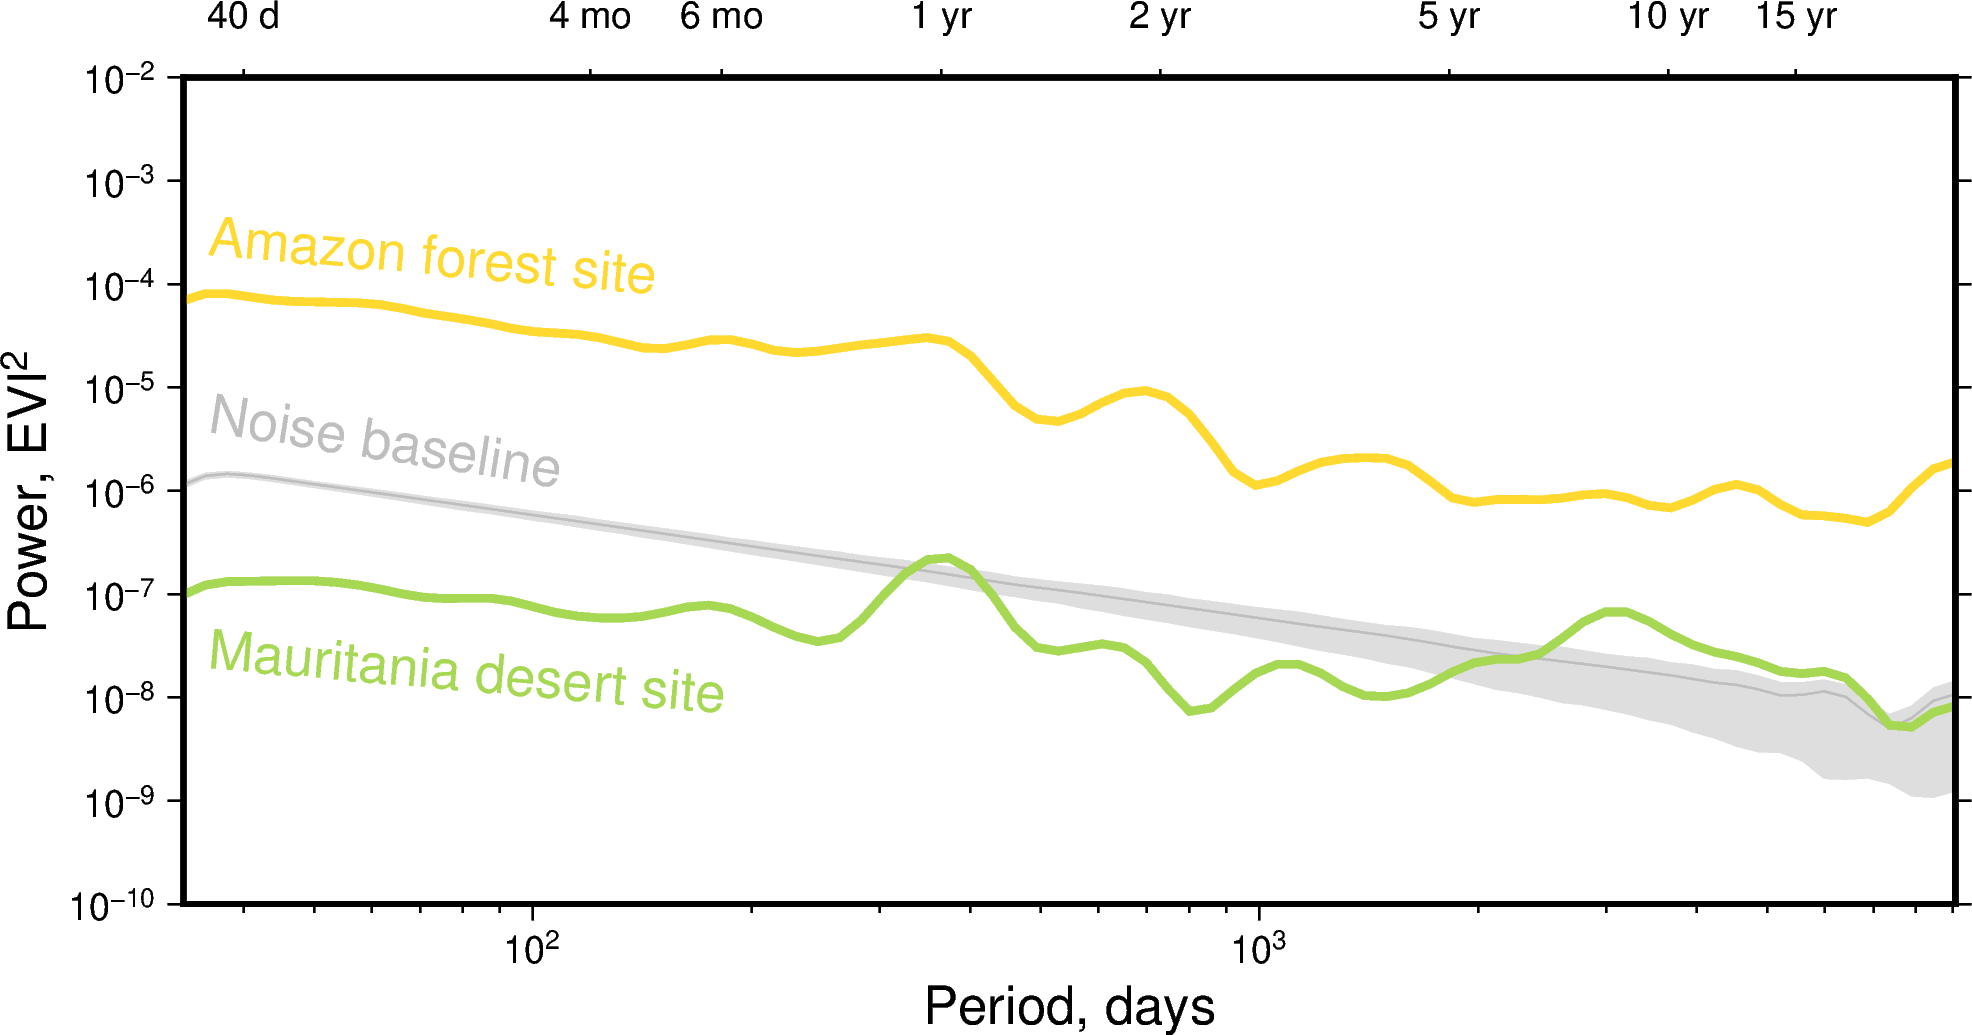

In [29]:
####################################
######### LOOP OVER POINTS #########
####################################

datasets_original_signals = []
# GMT PLOTTING
fig=pygmt.Figure()

########## PLOTTING ##########
# fig.basemap(region=[ min(base['frequency']), max(base['frequency']), min(sumpower_df_original['rectified_power']), max(base['mean_rect_power'])], projection="X-15cl/7cl",  frame=["SWe", 'xa1f3p+lFrequency, days@+-1@+' ,'ya1p+lPower, EVI@+2@+'])
fig.basemap(region=[ min(stats_noise['period']), max(stats_noise['period']), 1e-10, 1e-2], projection="X15cl/7cl",  frame=["SWe", 'xa1f3p+lPeriod, days' ,'ya1p+lPower, EVI@+2@+'])

# Mean line
fig.plot(x=stats_noise["period"], y=stats_noise["mean_rect_power"], pen="0.5p,gray", label="Mean rectified power")


# plot the interquantile range
fig.plot(
    x=list(stats_noise["period"]) + list(stats_noise["period"][::-1]),
    y=list(stats_noise["p25"]) + list(stats_noise["p75"][::-1]), transparency=50, fill="gray")





# for each point in the dataframe, extract the time series and run wavelet analysis but also add noise and run wavelet analysis on the noisy series
for i, row in coords_df.iterrows():
    if row["name"] not in ["6. Mauritania desert", "1. Amazon forest in Brazil"]:
        continue  # skip everything except mauritania-desert for testing
    
    # extract the timeseries: EVI values (sig1) and the time values (time_vals)
    ts = evi["EVI"].sel(lat=row['latitude'], lon=row['longitude'], method="nearest").compute()
    sig1 = ts.values

    # zeromean the Sig1 for running wavelet
    sig1_0_mean = sig1 - np.mean(sig1)

    # Convert datetime64 index to days since first observation
    times = evi.time.values
    time_vals = (times - times[0]) / np.timedelta64(1, 'D')  # Time in days as float
    
    ####################################
    ####### RUN WAVELET ANALYSIS #######
    ####################################
    _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, _, wavelet_power_df_mirrored = run_full_wavelet_analysis(sig1_0_mean, dt=16, mirror=True, wf='morlet', dj=0.1, om0=6, normmean=False, mirrormethod=3)

    original_length = len(sig1)
    start_index = 4 * original_length  # 5th repetition starts at (4 * original_length)
    end_index = 5 * original_length    # 5th repetition ends at (5 * original_length)

    #####################################
    ### DEALING WITH MIRRORRED RESULT ###
    #####################################
    # Because I mirrored the signal, there ia a lot of power that needs to be removed before plotting everything:
    # - I need to remove the power generated at periods greater than the length of the signal
    # - I also want to isolate power in the central domain (time-wise). 

    extended_time = wavelet_power_df_mirrored["time"].unique()
    # Define windows to remove excess power
    time_min = extended_time[start_index]
    time_max = extended_time[end_index]    
    period_min = 32    
    period_max = time_vals[-1]

    wavelet_power_df = wavelet_power_df_mirrored.copy() # Create a copy of the DataFrame so that we can store it separatelly

    # Apply the filter
    wavelet_power_df = wavelet_power_df[
        (wavelet_power_df["time"] >= time_min) & 
        (wavelet_power_df["time"] <= time_max) &
        (wavelet_power_df["period"] >= period_min) &
        (wavelet_power_df["period"] <= period_max)
    ]

    # change time value to restore the original time
    wavelet_power_df["time"] = wavelet_power_df["time"] - time_min
    wavelet_power_df = wavelet_power_df.reset_index()

    # overwrite the sumpower_df with the correct values for the selected windows
    sumpower_df_original = wavelet_power_df.groupby("period")[["rectified_power", "power"]].mean().reset_index()
    sumpower_df_original["frequency"] = 1 / sumpower_df_original["period"]
    # append to the list
    datasets_original_signals.append(sumpower_df_original)

    # create a new list to store the noise sumpower dfs
    sumpower_dfs_noisy = []
  
    # original signal, Wavelet power
    
    fig.plot(x=sumpower_df_original['period'], y=sumpower_df_original['rectified_power'], pen=f"2p,{palette[i-1]}", label="rectified") # rectified
    # fig.plot(x=sumpower_df_original['frequency'], y=sumpower_df_original['power'], pen="0.5p,black", label="unrectified") # unrectified

# Add text annotations
fig.basemap(region=[0, 15, 0, 7], projection="X15c/7c",  frame=["swne"])
fig.text(x=0.2, y=5.5, text="Amazon forest site", font=f"13p,Helvetica,{palette[5]}", justify="BL", angle=-5)
fig.text(x=0.2, y=4, text="Noise baseline", font="13p,Helvetica,gray", justify="BL", angle=-9)
fig.text(x=0.2, y=2, text="Mauritania desert site", font=f"13p,Helvetica,{palette[4]}", justify="BL", angle=-5)



# add period frame
fig.shift_origin(yshift="7c")
fig.basemap(region=[ stats_noise['period'].min(),stats_noise['period'].max(), 0,5], projection="X15cl/7c",  frame=["S"] )
ticks = [40, 120, 182, 365, 730, 1825, 3650, 5475]
lables = ['40 d', '4 mo', '6 mo', '1 yr', '2 yr', '5 yr', '10 yr', '15 yr']
# Add custom ticks using annotations
for tick, label in zip(ticks, lables):
    # Add ticks manually using annotations (style 'T' for ticks)
    fig.plot(x=[tick, tick], y=[0, 0.05], pen="0.5p,black")
    # Add text labels below the ticks
    fig.text(x=tick, y=0.3, text=label, font="9p", justify="BC")
fig.text(x=0.9, y=np.median(sorted(sumpower_df_original['period'].unique())), text="Period", font="12p,black")

# show
fig.show()

# save
fig.savefig("site_wavelet_plots/comparison-desert-forest-noise.png", dpi=600, transparent=True)
        